<a href="https://colab.research.google.com/github/vitriadwiernita/TUGAS-ANALISIS-KORELASI/blob/main/PROYEK_ETS_ANALISIS_REGRESI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAMA : VITRIA DWI ERNITA**

**NIM : 2430109040001**

**MATA KULIAH : ANALISIS REGRESI**

# **Analisis Hubungan Durasi Screen Time terhadap Tingkat Stres Menggunakan Regresi Linear Sederhana**

---
---

Perkembangan teknologi digital menyebabkan peningkatan penggunaan perangkat elektronik dalam kehidupan sehari-hari. Aktivitas seperti penggunaan smartphone dan media sosial telah menjadi bagian dari rutinitas banyak orang. Namun, penggunaan perangkat digital yang berlebihan diduga dapat memengaruhi kondisi kesehatan mental seseorang, seperti meningkatnya tingkat stres.

Oleh karena itu, penting untuk menganalisis apakah terdapat hubungan antara durasi penggunaan perangkat digital (screen time) dengan tingkat stres seseorang.

Analisis ini dapat dilakukan menggunakan regresi linear sederhana, yang bertujuan untuk mengetahui apakah perubahan pada satu variabel dapat memengaruhi variabel lainnya.

Saving KEBIASAAN DIGITAL VS MENTAL HEALTH.csv to KEBIASAAN DIGITAL VS MENTAL HEALTH.csv

=== NAMA KOLOM DATA ===
Index(['screen_time_hours', 'social_media_platforms_used', 'hours_on_TikTok',
       'sleep_hours', 'stress_level', 'mood_score'],
      dtype='object')

=== 5 DATA TERATAS ===
   screen_time_hours  social_media_platforms_used  hours_on_TikTok  \
0                103                            2               53   
1                 65                            5               35   
2                 91                            4               28   
3                 65                            3               25   
4                 21                            3               12   

   sleep_hours  stress_level  mood_score  
0           44            10           5  
1           62             8           8  
2           66             7           8  
3           65             7           9  
4           78             2          10  

=== DATA YANG DIGUNAKAN ===
  

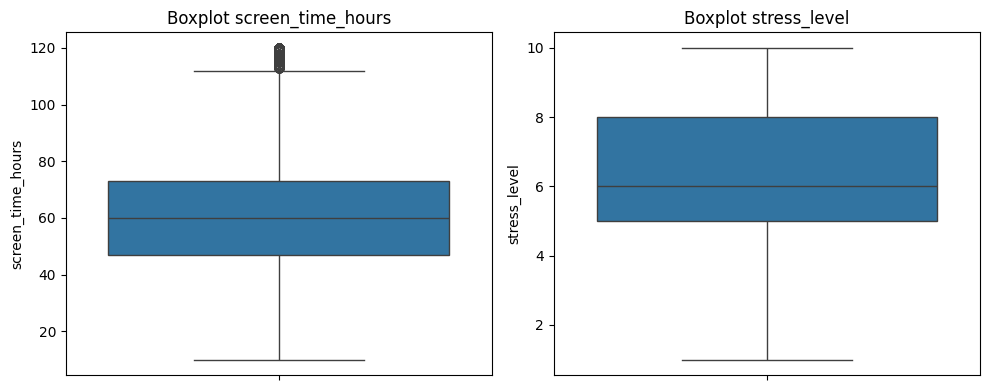


=== STATISTIK DESKRIPTIF ===
       screen_time_hours   stress_level
count      100000.000000  100000.000000
mean           60.035050       6.179590
std            19.870733       2.045409
min            10.000000       1.000000
25%            47.000000       5.000000
50%            60.000000       6.000000
75%            73.000000       8.000000
max           120.000000      10.000000


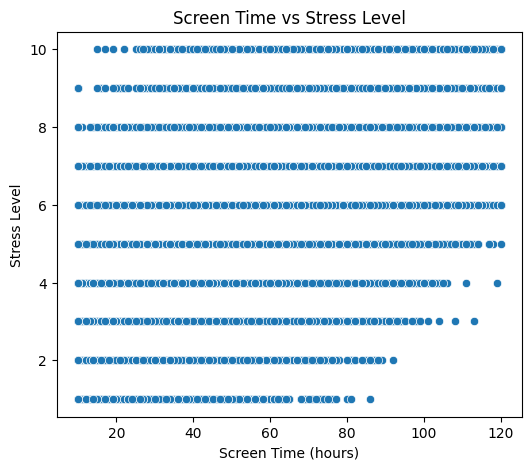


=== ANALISIS KORELASI (Pearson) ===
Koefisien Korelasi (r) = 0.4941
p-value = 0.0

=== ANALISIS REGRESI LINEAR ===

=== RINGKASAN MODEL ===
                            OLS Regression Results                            
Dep. Variable:           stress_level   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                 3.230e+04
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:46:01   Log-Likelihood:            -1.9946e+05
No. Observations:              100000   AIC:                         3.989e+05
Df Residuals:                   99998   BIC:                         3.989e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0

/tmp/ipykernel_342/4190614613.py:150: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = model.params[0]
/tmp/ipykernel_342/4190614613.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = model.params[1]


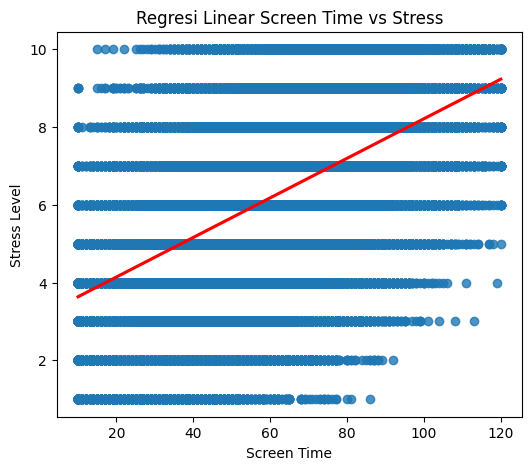


=== VALIDASI MODEL ===
MSE = 3.1588
R² = 0.2479

=== CONTOH PREDIKSI ===
Jika Screen Time = 50, maka Stress Level diprediksi = 5.6692


In [1]:
# ============================================
# ANALISIS REGRESI LINEAR SEDERHANA
# Screen Time vs Stress Level
# ============================================

# ============================================
# 1. IMPORT LIBRARY
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from google.colab import files
uploaded = files.upload()

# ============================================
# 2. IMPORT DATA
# ============================================

data = pd.read_csv("KEBIASAAN DIGITAL VS MENTAL HEALTH.csv", sep=";")

print("\n=== NAMA KOLOM DATA ===")
print(data.columns)

print("\n=== 5 DATA TERATAS ===")
print(data.head())

# ============================================
# 3. PILIH VARIABEL
# ============================================

data_reg = data[["screen_time_hours", "stress_level"]]

print("\n=== DATA YANG DIGUNAKAN ===")
print(data_reg.head())

# ============================================
# 4. CEK MISSING VALUES
# ============================================

print("\n=== MISSING VALUES ===")
print(data_reg.isnull().sum())

# ============================================
# 5. DETEKSI OUTLIER (IQR)
# ============================================

print("\n=== DETEKSI OUTLIER (IQR METHOD) ===")

def detect_outliers_iqr(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return lower_bound, upper_bound, outliers


for col in data_reg.columns:

    lb, ub, outliers = detect_outliers_iqr(data_reg[col])

    print(f"\nVariabel: {col}")
    print(f"Batas bawah: {round(lb,2)}")
    print(f"Batas atas : {round(ub,2)}")
    print(f"Jumlah outlier: {len(outliers)}")

# Boxplot

plt.figure(figsize=(10,4))

for i, col in enumerate(data_reg.columns):
    plt.subplot(1,2,i+1)
    sns.boxplot(y=data_reg[col])
    plt.title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

# ============================================
# 6. STATISTIK DESKRIPTIF
# ============================================

print("\n=== STATISTIK DESKRIPTIF ===")
print(data_reg.describe())

# ============================================
# 7. SCATTER PLOT
# ============================================

plt.figure(figsize=(6,5))

sns.scatterplot(
    x=data_reg["screen_time_hours"],
    y=data_reg["stress_level"]
)

plt.title("Screen Time vs Stress Level")
plt.xlabel("Screen Time (hours)")
plt.ylabel("Stress Level")

plt.show()

# ============================================
# 8. ANALISIS KORELASI
# ============================================

print("\n=== ANALISIS KORELASI (Pearson) ===")

correlation, p_value = stats.pearsonr(
    data_reg["screen_time_hours"],
    data_reg["stress_level"]
)

print(f"Koefisien Korelasi (r) = {round(correlation,4)}")
print(f"p-value = {round(p_value,6)}")

# ============================================
# 9. ANALISIS REGRESI LINEAR
# ============================================

print("\n=== ANALISIS REGRESI LINEAR ===")

X = data_reg["screen_time_hours"]
Y = data_reg["stress_level"]

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print("\n=== RINGKASAN MODEL ===")
print(model.summary())

# ============================================
# 10. PERSAMAAN REGRESI
# ============================================

intercept = model.params[0]
slope = model.params[1]

print("\n=== PERSAMAAN REGRESI ===")
print(f"Stress_Level = {round(intercept,4)} + {round(slope,4)} * Screen_Time")

# ============================================
# 11. VISUALISASI GARIS REGRESI
# ============================================

plt.figure(figsize=(6,5))

sns.regplot(
    x=data_reg["screen_time_hours"],
    y=data_reg["stress_level"],
    line_kws={"color":"red"}
)

plt.title("Regresi Linear Screen Time vs Stress")
plt.xlabel("Screen Time")
plt.ylabel("Stress Level")

plt.show()

# ============================================
# 12. VALIDASI MODEL
# ============================================

print("\n=== VALIDASI MODEL ===")

X_train, X_test, y_train, y_test = train_test_split(
    data_reg[["screen_time_hours"]],
    data_reg["stress_level"],
    test_size=0.2,
    random_state=42
)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model_train = sm.OLS(y_train, X_train_const).fit()

predictions = model_train.predict(X_test_const)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MSE = {round(mse,4)}")
print(f"R² = {round(r2,4)}")

# ============================================
# 13. PREDIKSI NILAI BARU
# ============================================

nilai_baru = 50

prediksi = intercept + slope * nilai_baru

print("\n=== CONTOH PREDIKSI ===")
print(f"Jika Screen Time = {nilai_baru}, maka Stress Level diprediksi = {round(prediksi,4)}")